In [362]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 해결
plt.rcParams['axes.unicode_minus'] = False    

In [363]:
df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')

print(len(df))

# 동자동 트윈시티 남산 매물을 이상치로 판단하고 제거
target = df[(df['BLDG_NM']=='트윈시티 남산') & (df['ARCH_AREA']==488.54)]

df = df.drop(target.index)

# 입주권 제거
df = df[df['RGHT_SE'] != '입주권'].copy()

print(len(df))

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_67552/41715357.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')


794606
789955


In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 789955 entries, 0 to 794605
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  789955 non-null  int64  
 1   CGG_CD      789955 non-null  int64  
 2   CGG_NM      789955 non-null  object 
 3   STDG_CD     789955 non-null  int64  
 4   STDG_NM     789955 non-null  object 
 5   BLDG_NM     736793 non-null  object 
 6   CTRT_DAY    789955 non-null  object 
 7   THING_AMT   789955 non-null  int64  
 8   ARCH_AREA   789955 non-null  float64
 9   LAND_AREA   629015 non-null  float64
 10  FLR         736844 non-null  float64
 11  RGHT_SE     2389 non-null    object 
 12  ARCH_YR     789955 non-null  int64  
 13  BLDG_USG    789955 non-null  object 
 14  DCLR_SE     212915 non-null  object 
 15  CTRT_YEAR   789955 non-null  int64  
dtypes: float64(3), int64(6), object(7)
memory usage: 102.5+ MB


In [365]:
df['CTRT_DAY']

0         2019-04-25
1         2019-03-16
2         2019-02-21
3         2019-01-21
4         2019-01-03
             ...    
794601    2023-11-21
794602    2023-11-14
794603    2023-11-13
794604    2023-11-11
794605    2023-11-09
Name: CTRT_DAY, Length: 789955, dtype: object

In [366]:
df['bungi'] = df['CTRT_DAY'].astype(str).str[5:7]
df['bungi_int'] = df['bungi'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 789955 entries, 0 to 794605
Data columns (total 18 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  789955 non-null  int64  
 1   CGG_CD      789955 non-null  int64  
 2   CGG_NM      789955 non-null  object 
 3   STDG_CD     789955 non-null  int64  
 4   STDG_NM     789955 non-null  object 
 5   BLDG_NM     736793 non-null  object 
 6   CTRT_DAY    789955 non-null  object 
 7   THING_AMT   789955 non-null  int64  
 8   ARCH_AREA   789955 non-null  float64
 9   LAND_AREA   629015 non-null  float64
 10  FLR         736844 non-null  float64
 11  RGHT_SE     2389 non-null    object 
 12  ARCH_YR     789955 non-null  int64  
 13  BLDG_USG    789955 non-null  object 
 14  DCLR_SE     212915 non-null  object 
 15  CTRT_YEAR   789955 non-null  int64  
 16  bungi       789955 non-null  object 
 17  bungi_int   789955 non-null  int64  
dtypes: float64(3), int64(7), object(8)
memory usage: 

In [367]:
# 1. 함수 정의 (매개변수 x는 행의 특정 값)
def get_bungi(x):
    if x < 4:
        return 'Q1'
    elif x < 7:
        return 'Q2'
    elif x < 10:
        return 'Q3'
    else:
        return 'Q4'

# 2. apply 함수를 이용해 bungi_int 컬럼의 모든 값에 적용
df['bungi'] = df['CTRT_YEAR'].astype(str) + df['bungi_int'].apply(get_bungi)

df['bungi']

0         2019Q2
1         2019Q1
2         2019Q1
3         2019Q1
4         2019Q1
           ...  
794601    2023Q4
794602    2023Q4
794603    2023Q4
794604    2023Q4
794605    2023Q4
Name: bungi, Length: 789955, dtype: object

In [368]:
len(df)

789955

In [369]:
# 2024Q4 데이터 제거
remove = df[df['bungi']=='2024Q4']
df = df.drop(remove.index)

# 잘 제거 되었는지 확인
df['bungi'].value_counts().sort_index(ascending=False)

bungi
2024Q3    27308
2024Q2    26359
2024Q1    17811
2023Q4    14229
2023Q3    19434
2023Q2    18922
2023Q1    13899
2022Q4     8809
2022Q3    12130
2022Q2    22515
2022Q1    16965
2021Q4    22317
2021Q3    31859
2021Q2    37432
2021Q1    36718
2020Q4    39455
2020Q3    42004
2020Q2    46573
2020Q1    38056
2019Q4    55195
2019Q3    38335
2019Q2    29180
2019Q1    17094
2018Q4    20805
2018Q3    50140
2018Q2    31926
2018Q1    53613
Name: count, dtype: int64

In [370]:
len(df)

789083

In [371]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 789083 entries, 0 to 794605
Data columns (total 18 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  789083 non-null  int64  
 1   CGG_CD      789083 non-null  int64  
 2   CGG_NM      789083 non-null  object 
 3   STDG_CD     789083 non-null  int64  
 4   STDG_NM     789083 non-null  object 
 5   BLDG_NM     735942 non-null  object 
 6   CTRT_DAY    789083 non-null  object 
 7   THING_AMT   789083 non-null  int64  
 8   ARCH_AREA   789083 non-null  float64
 9   LAND_AREA   628143 non-null  float64
 10  FLR         735993 non-null  float64
 11  RGHT_SE     2382 non-null    object 
 12  ARCH_YR     789083 non-null  int64  
 13  BLDG_USG    789083 non-null  object 
 14  DCLR_SE     212043 non-null  object 
 15  CTRT_YEAR   789083 non-null  int64  
 16  bungi       789083 non-null  object 
 17  bungi_int   789083 non-null  int64  
dtypes: float64(3), int64(7), object(8)
memory usage: 

In [372]:
# 평당가 구하기
# 전용면적(평수): 부동산에서 순수하게 거주할 수 있는 면적
# df 데이터에서 나타내는 건물면적: 전용면적
# 1평은 약 **3.3058$m^2$**에 해당
# 평당가 = 건물가격 / 건물면적 * 3.3058
df['unit_price'] = df['THING_AMT'] / df['ARCH_AREA'] * (3.3058)

In [373]:
# 건물용도별 분기별 평균 거래금액 데이터
mean_amt_bungi = df.groupby(['BLDG_USG','bungi'], as_index=False)['THING_AMT'].mean() 
mean_amt_bungi

,BLDG_USG,bungi,THING_AMT
0,단독다가구,2018Q1,96360.570525
1,단독다가구,2018Q2,94796.964196
2,단독다가구,2018Q3,96637.290688
3,단독다가구,2018Q4,97729.678756
4,단독다가구,2019Q1,109494.958472
...,...,...,...
103,오피스텔,2023Q3,27920.815764
104,오피스텔,2023Q4,27462.876664
105,오피스텔,2024Q1,30687.710324
106,오피스텔,2024Q2,28701.209532


In [374]:
# 건물용도별로 나누어 분기별 건물가격 확인
dan = mean_amt_bungi[mean_amt_bungi['BLDG_USG']=='단독다가구'].copy()
apt = mean_amt_bungi[mean_amt_bungi['BLDG_USG']=='아파트'].copy()
yeon = mean_amt_bungi[mean_amt_bungi['BLDG_USG']=='연립다세대'].copy()
off = mean_amt_bungi[mean_amt_bungi['BLDG_USG']=='오피스텔'].copy()

In [375]:
# 건물용도별 분기별 평균 평당가 데이터
mean_unit_price_bungi = df.groupby(['BLDG_USG','bungi'], as_index=False)['unit_price'].mean() 
mean_unit_price_bungi

,BLDG_USG,bungi,unit_price
0,단독다가구,2018Q1,2105.482655
1,단독다가구,2018Q2,2113.868588
2,단독다가구,2018Q3,2253.119746
3,단독다가구,2018Q4,2266.655098
4,단독다가구,2019Q1,2381.122361
...,...,...,...
103,오피스텔,2023Q3,2746.923004
104,오피스텔,2023Q4,2844.030490
105,오피스텔,2024Q1,2959.269928
106,오피스텔,2024Q2,2785.204712


In [390]:
# 건물용도별로 나누어 분기별 건물가격 확인
dan2 = mean_unit_price_bungi[mean_unit_price_bungi['BLDG_USG']=='단독다가구'].copy()
apt2 = mean_unit_price_bungi[mean_unit_price_bungi['BLDG_USG']=='아파트'].copy()
yeon2 = mean_unit_price_bungi[mean_unit_price_bungi['BLDG_USG']=='연립다세대'].copy()
off2 = mean_unit_price_bungi[mean_unit_price_bungi['BLDG_USG']=='오피스텔'].copy()

In [376]:
dan

,BLDG_USG,bungi,THING_AMT
0,단독다가구,2018Q1,96360.570525
1,단독다가구,2018Q2,94796.964196
2,단독다가구,2018Q3,96637.290688
3,단독다가구,2018Q4,97729.678756
4,단독다가구,2019Q1,109494.958472
5,단독다가구,2019Q2,98290.017766
6,단독다가구,2019Q3,109507.282856
7,단독다가구,2019Q4,108779.934388
8,단독다가구,2020Q1,109052.854917
9,단독다가구,2020Q2,119029.012837


In [ ]:
# 건물용도별 분기별 건물가격의 증감폭
dan['diff'] = dan['THING_AMT'].diff().fillna(0)
apt['diff'] = apt['THING_AMT'].diff().fillna(0)
yeon['diff'] = yeon['THING_AMT'].diff().fillna(0)
off['diff'] = off['THING_AMT'].diff().fillna(0)

In [391]:
# 건물용도별 분기별 평당가의 증감폭
dan2['diff'] = dan2['unit_price'].diff().fillna(0)
apt2['diff'] = apt2['unit_price'].diff().fillna(0)
yeon2['diff'] = yeon2['unit_price'].diff().fillna(0)
off2['diff'] = off2['unit_price'].diff().fillna(0)

In [392]:
dan2

,BLDG_USG,bungi,unit_price,diff
0,단독다가구,2018Q1,2105.482655,0.000000
1,단독다가구,2018Q2,2113.868588,8.385933
2,단독다가구,2018Q3,2253.119746,139.251158
3,단독다가구,2018Q4,2266.655098,13.535352
4,단독다가구,2019Q1,2381.122361,114.467262
5,단독다가구,2019Q2,2264.123107,-116.999254
6,단독다가구,2019Q3,2428.360421,164.237315
7,단독다가구,2019Q4,2613.198334,184.837913
8,단독다가구,2020Q1,2431.267474,-181.930861
9,단독다가구,2020Q2,2647.984296,216.716822


In [378]:
dan

,BLDG_USG,bungi,THING_AMT,diff
0,단독다가구,2018Q1,96360.570525,0.000000
1,단독다가구,2018Q2,94796.964196,-1563.606329
2,단독다가구,2018Q3,96637.290688,1840.326493
3,단독다가구,2018Q4,97729.678756,1092.388068
4,단독다가구,2019Q1,109494.958472,11765.279715
5,단독다가구,2019Q2,98290.017766,-11204.940705
6,단독다가구,2019Q3,109507.282856,11217.265090
7,단독다가구,2019Q4,108779.934388,-727.348468
8,단독다가구,2020Q1,109052.854917,272.920528
9,단독다가구,2020Q2,119029.012837,9976.157920


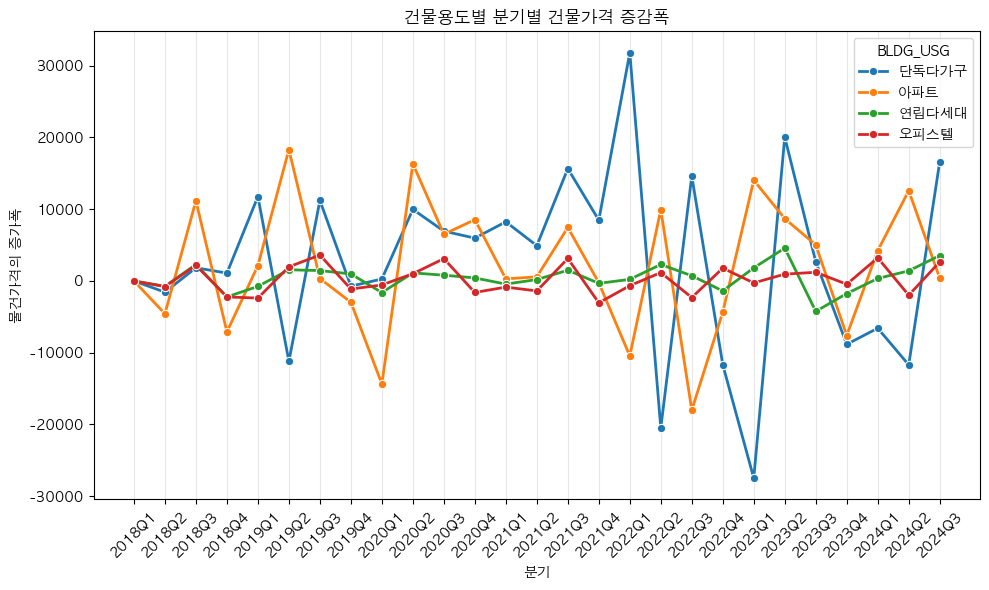

In [398]:
# 건물용도 통합본 생성
df_all = pd.concat([dan, apt, yeon, off])

# 건물용도별 분기별 건물 가격의 증감폭
plt.figure(figsize=(10,6))
sns.lineplot(data=df_all, x='bungi', y='diff', hue='BLDG_USG',
             marker='o', linewidth=2)
plt.title("건물용도별 분기별 건물가격 증감폭")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

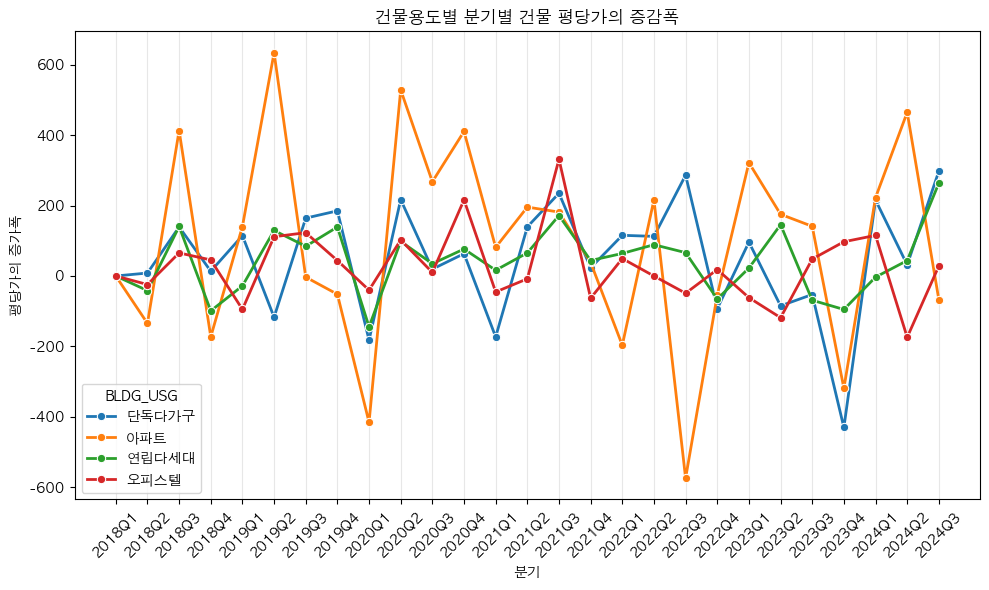

In [393]:
# 건물용도 통합본 생성
df_all2 = pd.concat([dan2, apt2, yeon2, off2])

# 건물용도별 분기별 건물 평당가의 증감폭
plt.figure(figsize=(10,6))
sns.lineplot(data=df_all2, x='bungi', y='diff', hue='BLDG_USG',
             marker='o', linewidth=2)
plt.title("건물용도별 분기별 건물 평당가의 증감폭")
plt.xlabel("분기")
plt.ylabel("평당가의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

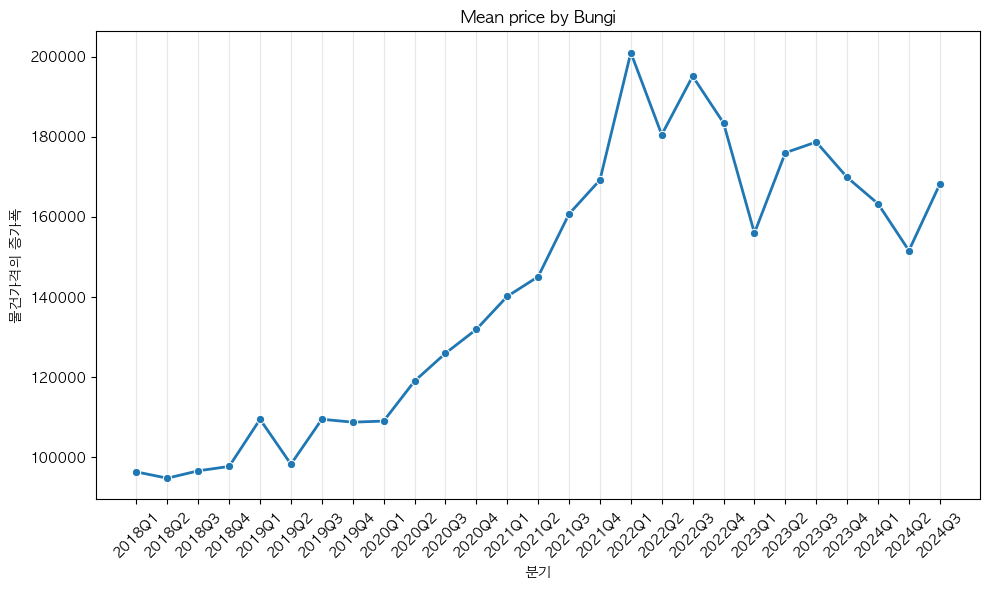

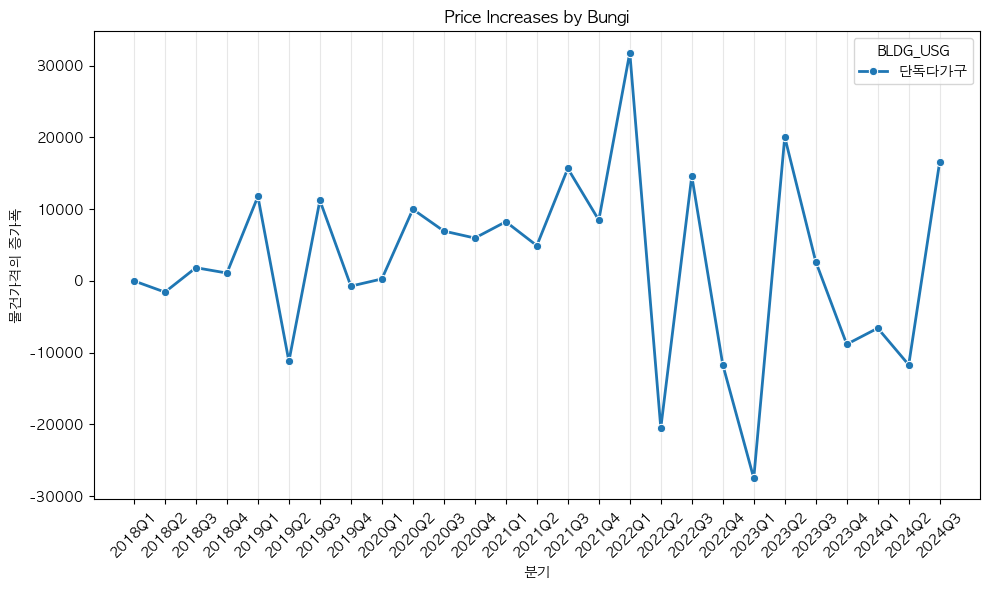

In [382]:
# 단독다가구 분기별 평균 건물금액
plt.figure(figsize=(10,6))
sns.lineplot(data=dan, x='bungi', y='THING_AMT',
             marker='o', linewidth=2)

# 4주기마다 수직선 및 마커 색상 변경
for i, label in enumerate(dan['bungi']):
    # 4분기(04)인 지점마다 실행 (또는 i % 4 == 3)
    if label.endswith('04'):
        # 수직 가이드라인 추가
        plt.axvline(x=i, color='hotpink', linestyle='--', alpha=0.3)
        
        # 특정 마커만 다른 색으로 덧칠하기 (index i의 x, y값 추출)
        plt.scatter(i, dan['THING_AMT'].iloc[i], color='hotpink', s=100, zorder=5, label='Year End' if i==3 else "")
        
plt.title("Mean price by Bungi")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# 단독다가구 분기별 증가폭
plt.figure(figsize=(10,6))
sns.lineplot(data=dan, x='bungi', y='diff', hue='BLDG_USG',
             marker='o', linewidth=2)

# 4주기마다 수직선 및 마커 색상 변경
for i, label in enumerate(dan['bungi']):
    # 4분기(04)인 지점마다 실행 (또는 i % 4 == 3)
    if label.endswith('04'):
        # 수직 가이드라인 추가
        plt.axvline(x=i, color='hotpink', linestyle='--', alpha=0.3)
        
        # 특정 마커만 다른 색으로 덧칠하기 (index i의 x, y값 추출)
        plt.scatter(i, dan['diff'].iloc[i], color='hotpink', s=100, zorder=5, label='Year End' if i==3 else "")
        
plt.title("Price Increases by Bungi")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

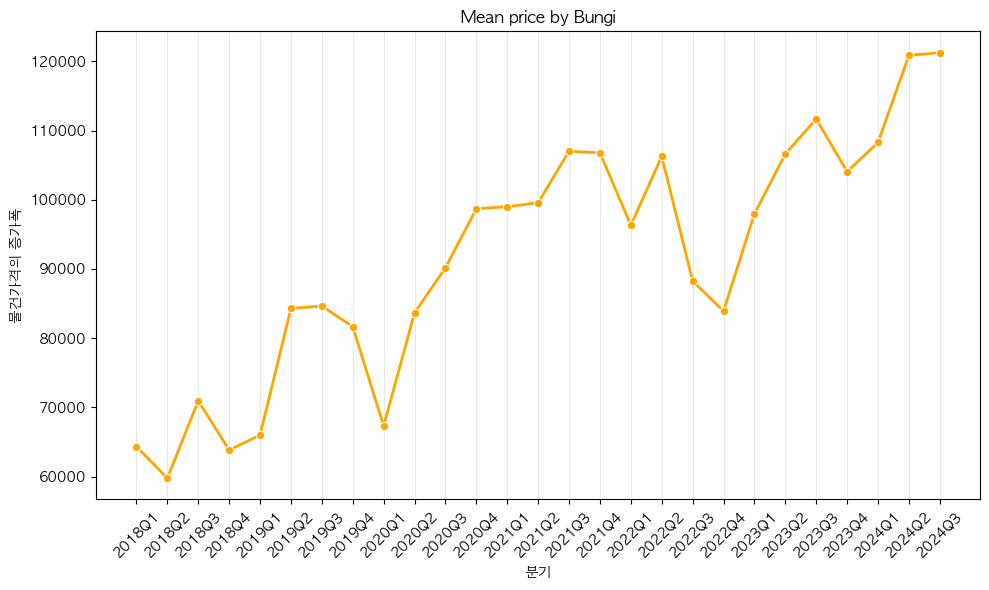

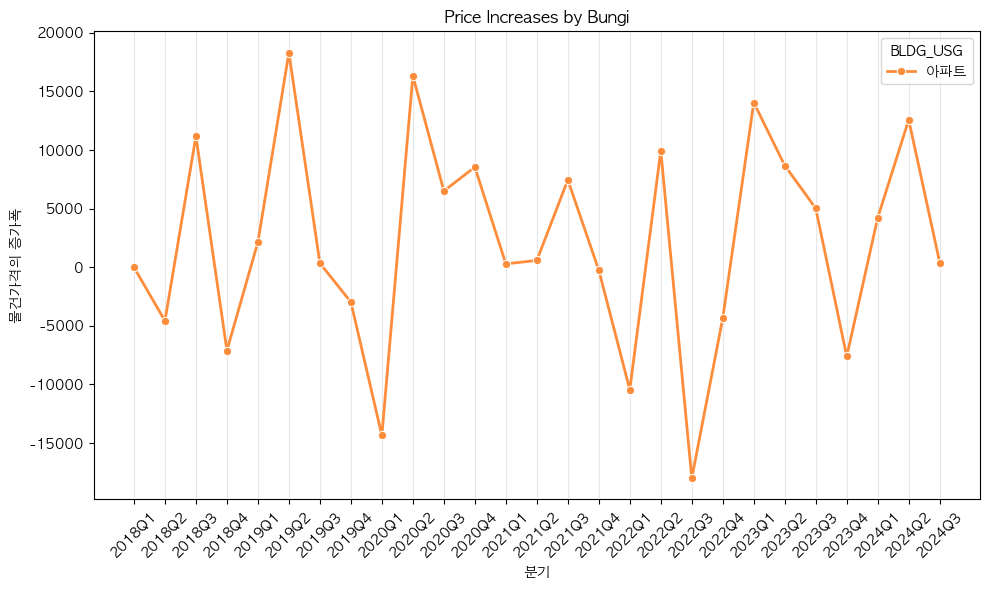

In [383]:
# 아파트 분기별 평균 건물금액
plt.figure(figsize=(10,6))
sns.lineplot(data=apt, x='bungi', y='THING_AMT', color='orange',
             marker='o', linewidth=2)

# 4주기마다 수직선 및 마커 색상 변경
for i, label in enumerate(apt['bungi']):
    # 4분기(04)인 지점마다 실행 (또는 i % 4 == 3)
    if label.endswith('04'):
        # 수직 가이드라인 추가
        plt.axvline(x=i, color='hotpink', linestyle='--', alpha=0.3)
        
        # 특정 마커만 다른 색으로 덧칠하기 (index i의 x, y값 추출)
        plt.scatter(i, apt['THING_AMT'].iloc[i], color='hotpink', s=100, zorder=5, label='Year End' if i==3 else "")
        
plt.title("Mean price by Bungi")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 아파트 분기별 증가폭
plt.figure(figsize=(10,6))
sns.lineplot(data=apt, x='bungi', y='diff', hue='BLDG_USG',
             marker='o', linewidth=2, palette='Oranges')

# 4주기마다 수직선 및 마커 색상 변경
for i, label in enumerate(apt['bungi']):
    # 4분기(04)인 지점마다 실행 (또는 i % 4 == 3)
    if label.endswith('04'):
        # 수직 가이드라인 추가
        plt.axvline(x=i, color='hotpink', linestyle='--', alpha=0.3)
        
        # 특정 마커만 다른 색으로 덧칠하기 (index i의 x, y값 추출)
        plt.scatter(i, apt['diff'].iloc[i], color='hotpink', s=100, zorder=5, label='Year End' if i==3 else "")
     
plt.title("Price Increases by Bungi")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

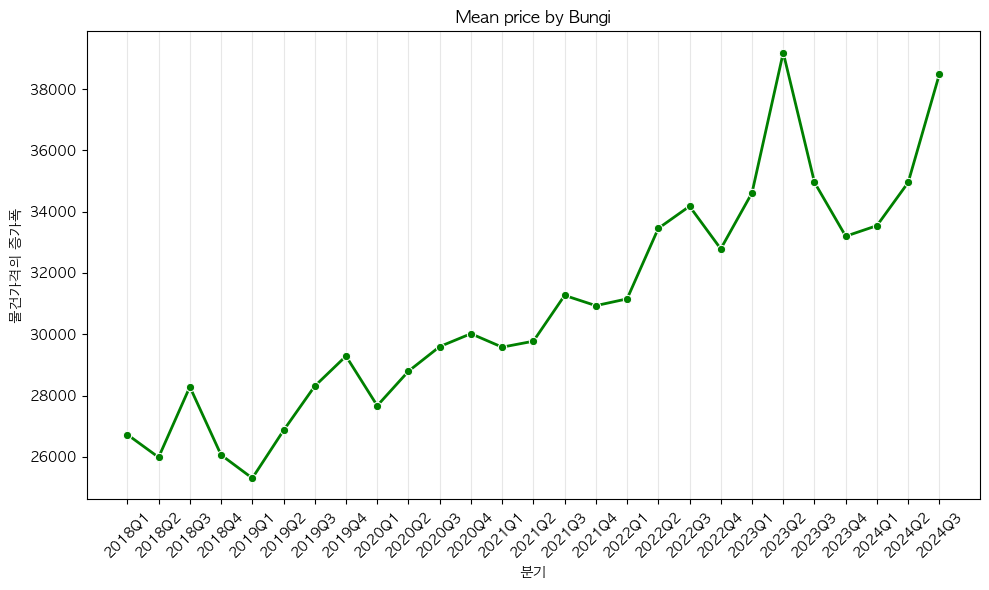

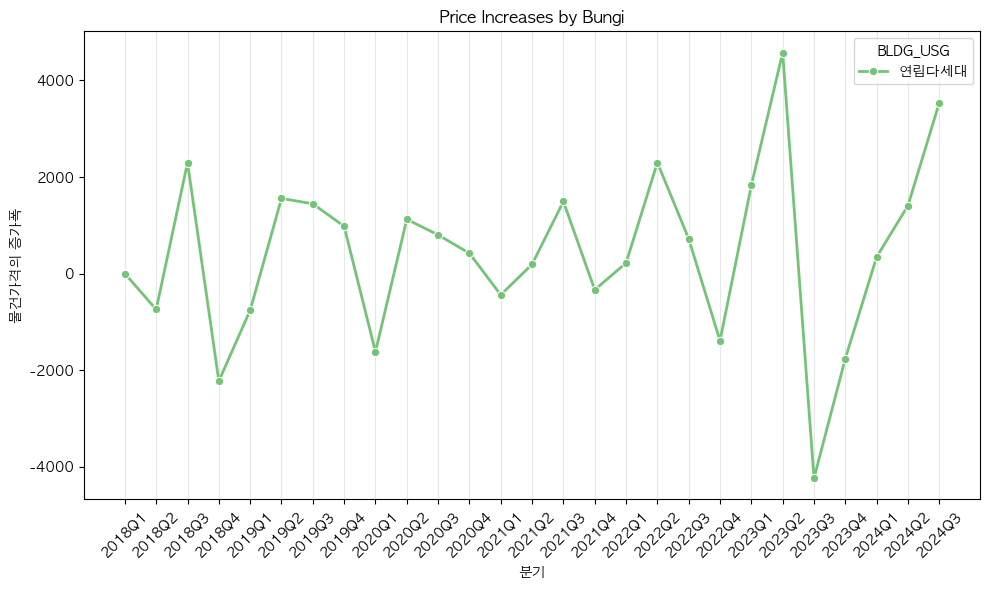

In [384]:
# 연립다세대 분기별 평균 건물금액
plt.figure(figsize=(10,6))
sns.lineplot(data=yeon, x='bungi', y='THING_AMT', color='green',
             marker='o', linewidth=2)

# 4주기마다 수직선 및 마커 색상 변경
for i, label in enumerate(yeon['bungi']):
    # 4분기(04)인 지점마다 실행 (또는 i % 4 == 3)
    if label.endswith('04'):
        # 수직 가이드라인 추가
        plt.axvline(x=i, color='hotpink', linestyle='--', alpha=0.3)
        
        # 특정 마커만 다른 색으로 덧칠하기 (index i의 x, y값 추출)
        plt.scatter(i, yeon['THING_AMT'].iloc[i], color='hotpink', s=100, zorder=5, label='Year End' if i==3 else "")
        
plt.title("Mean price by Bungi")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 연립다세대 분기별 증가폭
plt.figure(figsize=(10,6))
sns.lineplot(data=yeon, x='bungi', y='diff', hue='BLDG_USG',
             marker='o', linewidth=2, palette='Greens')

# 4주기마다 수직선 및 마커 색상 변경
for i, label in enumerate(yeon['bungi']):
    # 4분기(04)인 지점마다 실행 (또는 i % 4 == 3)
    if label.endswith('04'):
        # 수직 가이드라인 추가
        plt.axvline(x=i, color='hotpink', linestyle='--', alpha=0.3)
        
        # 특정 마커만 다른 색으로 덧칠하기 (index i의 x, y값 추출)
        plt.scatter(i, yeon['diff'].iloc[i], color='hotpink', s=100, zorder=5, label='Year End' if i==3 else "")
     
plt.title("Price Increases by Bungi")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

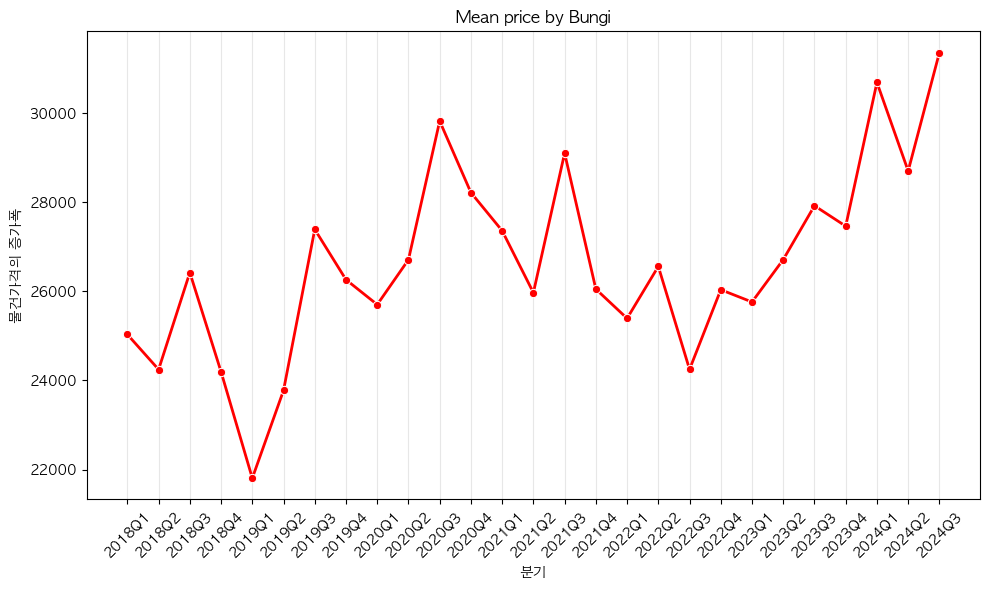

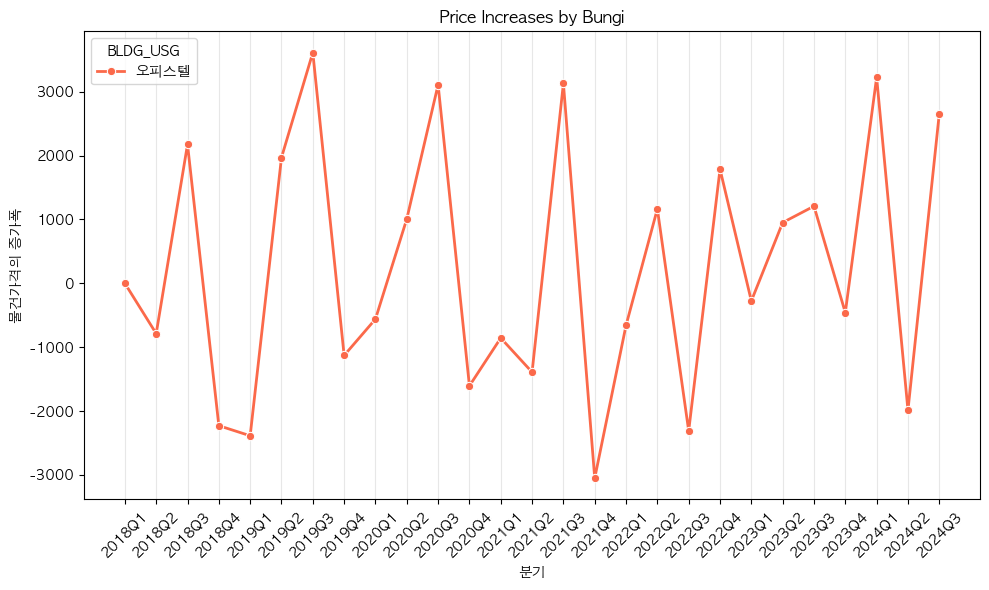

In [385]:
# 오피스텔 분기별 평균 건물금액
plt.figure(figsize=(10,6))
sns.lineplot(data=off, x='bungi', y='THING_AMT', color='red',
             marker='o', linewidth=2)

# 4주기마다 수직선 및 마커 색상 변경
for i, label in enumerate(off['bungi']):
    # 4분기(04)인 지점마다 실행 (또는 i % 4 == 3)
    if label.endswith('04'):
        # 수직 가이드라인 추가
        plt.axvline(x=i, color='hotpink', linestyle='--', alpha=0.3)
        
        # 특정 마커만 다른 색으로 덧칠하기 (index i의 x, y값 추출)
        plt.scatter(i, off['THING_AMT'].iloc[i], color='hotpink', s=100, zorder=5, label='Year End' if i==3 else "")
        
plt.title("Mean price by Bungi")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 오피스텔 분기별 증가폭
plt.figure(figsize=(10,6))
sns.lineplot(data=off, x='bungi', y='diff', hue='BLDG_USG',
             marker='o', linewidth=2, palette='Reds')

# 4주기마다 수직선 및 마커 색상 변경
for i, label in enumerate(off['bungi']):
    # 4분기(04)인 지점마다 실행 (또는 i % 4 == 3)
    if label.endswith('04'):
        # 수직 가이드라인 추가
        plt.axvline(x=i, color='hotpink', linestyle='--', alpha=0.3)
        
        # 특정 마커만 다른 색으로 덧칠하기 (index i의 x, y값 추출)
        plt.scatter(i, off['diff'].iloc[i], color='hotpink', s=100, zorder=5, label='Year End' if i==3 else "")
     
plt.title("Price Increases by Bungi")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

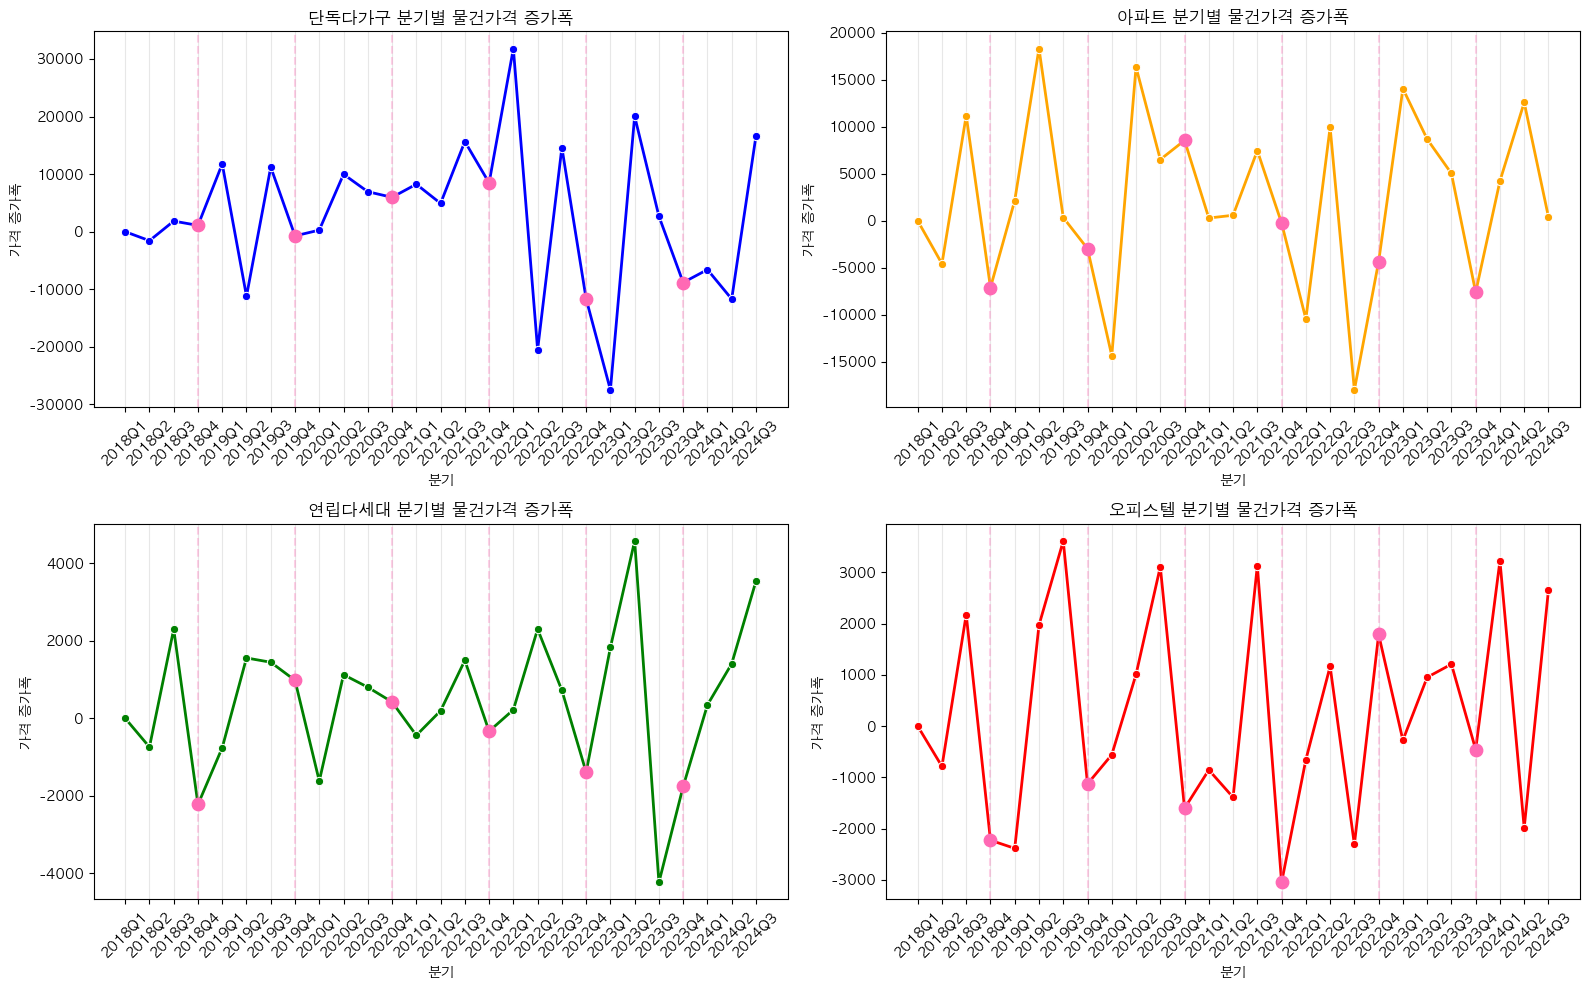

In [395]:
# 건물용도별 분기별 물건가격 증가폭 그래프 비교

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 설정 및 데이터 준비
plt.rcParams['axes.unicode_minus'] = False 
target_dfs = [dan, apt, yeon, off]
titles = ['단독다가구', '아파트', '연립다세대', '오피스텔']
colors = ['Blues', 'Oranges', 'Greens', 'Reds']

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐 반복문을 쉽게 만듦

for i, df in enumerate(target_dfs):
    ax = axes[i]
    
    # 그래프 그리기 (palette 대신 단일 색상 사용 시 color 인자 활용)
    sns.lineplot(data=df, x='bungi', y='diff', marker='o', 
                 linewidth=2, ax=ax, color=colors[i][:-1].lower()) # 예: 'Blues' -> 'blue'
    
    # 4주기(연말) 강조 로직
    for j, label in enumerate(df['bungi']):
        if label.endswith('Q4'):
            ax.axvline(x=j, color='hotpink', linestyle='--', alpha=0.3)
            ax.scatter(j, df['diff'].iloc[j], color='hotpink', s=80, zorder=5)
    
    # 개별 그래프 설정
    ax.set_title(f"{titles[i]} 분기별 물건가격 증가폭", fontsize=12)
    ax.set_xlabel("분기")
    ax.set_ylabel("가격 증가폭")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='x', alpha=0.3)

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

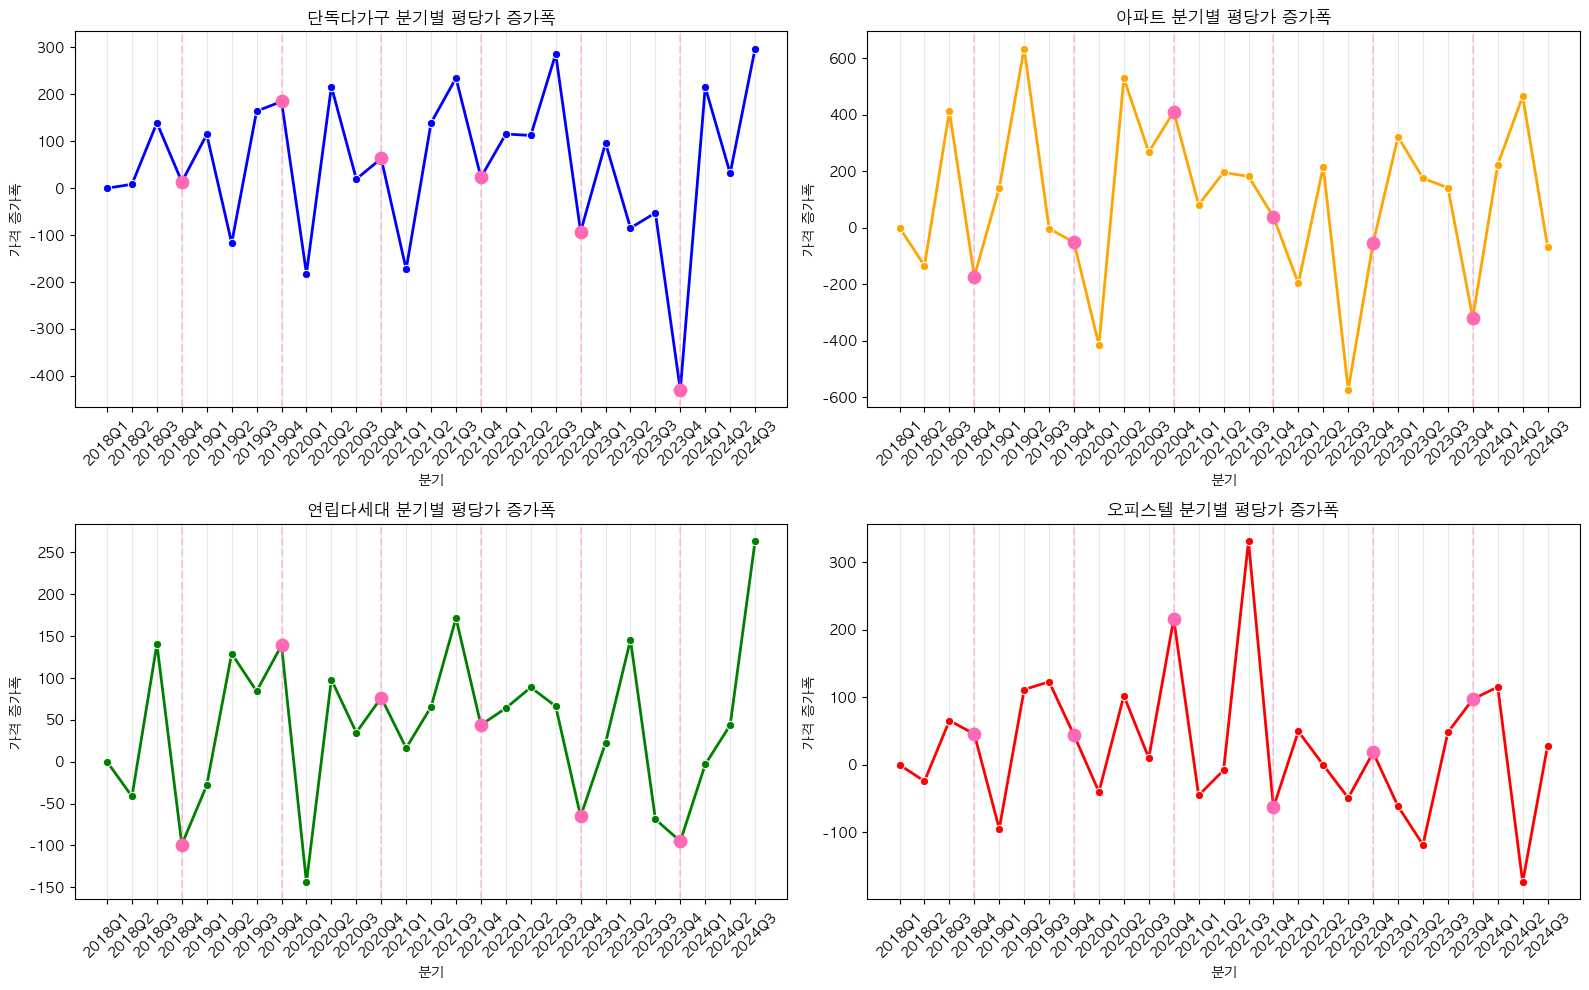

In [396]:
# 건물용도별 분기별 평당가의 증가폭 그래프 비교

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 설정 및 데이터 준비
plt.rcParams['axes.unicode_minus'] = False 
target_dfs = [dan2, apt2, yeon2, off2]
titles = ['단독다가구', '아파트', '연립다세대', '오피스텔']
colors = ['Blues', 'Oranges', 'Greens', 'Reds']

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐 반복문을 쉽게 만듦

for i, df in enumerate(target_dfs):
    ax = axes[i]
    
    # 그래프 그리기 (palette 대신 단일 색상 사용 시 color 인자 활용)
    sns.lineplot(data=df, x='bungi', y='diff', marker='o', 
                 linewidth=2, ax=ax, color=colors[i][:-1].lower()) # 예: 'Blues' -> 'blue'
    
    # 4주기(연말) 강조 로직
    for j, label in enumerate(df['bungi']):
        if label.endswith('Q4'):
            ax.axvline(x=j, color='hotpink', linestyle='--', alpha=0.3)
            ax.scatter(j, df['diff'].iloc[j], color='hotpink', s=80, zorder=5)
    
    # 개별 그래프 설정
    ax.set_title(f"{titles[i]} 분기별 평당가 증가폭", fontsize=12)
    ax.set_xlabel("분기")
    ax.set_ylabel("가격 증가폭")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='x', alpha=0.3)

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

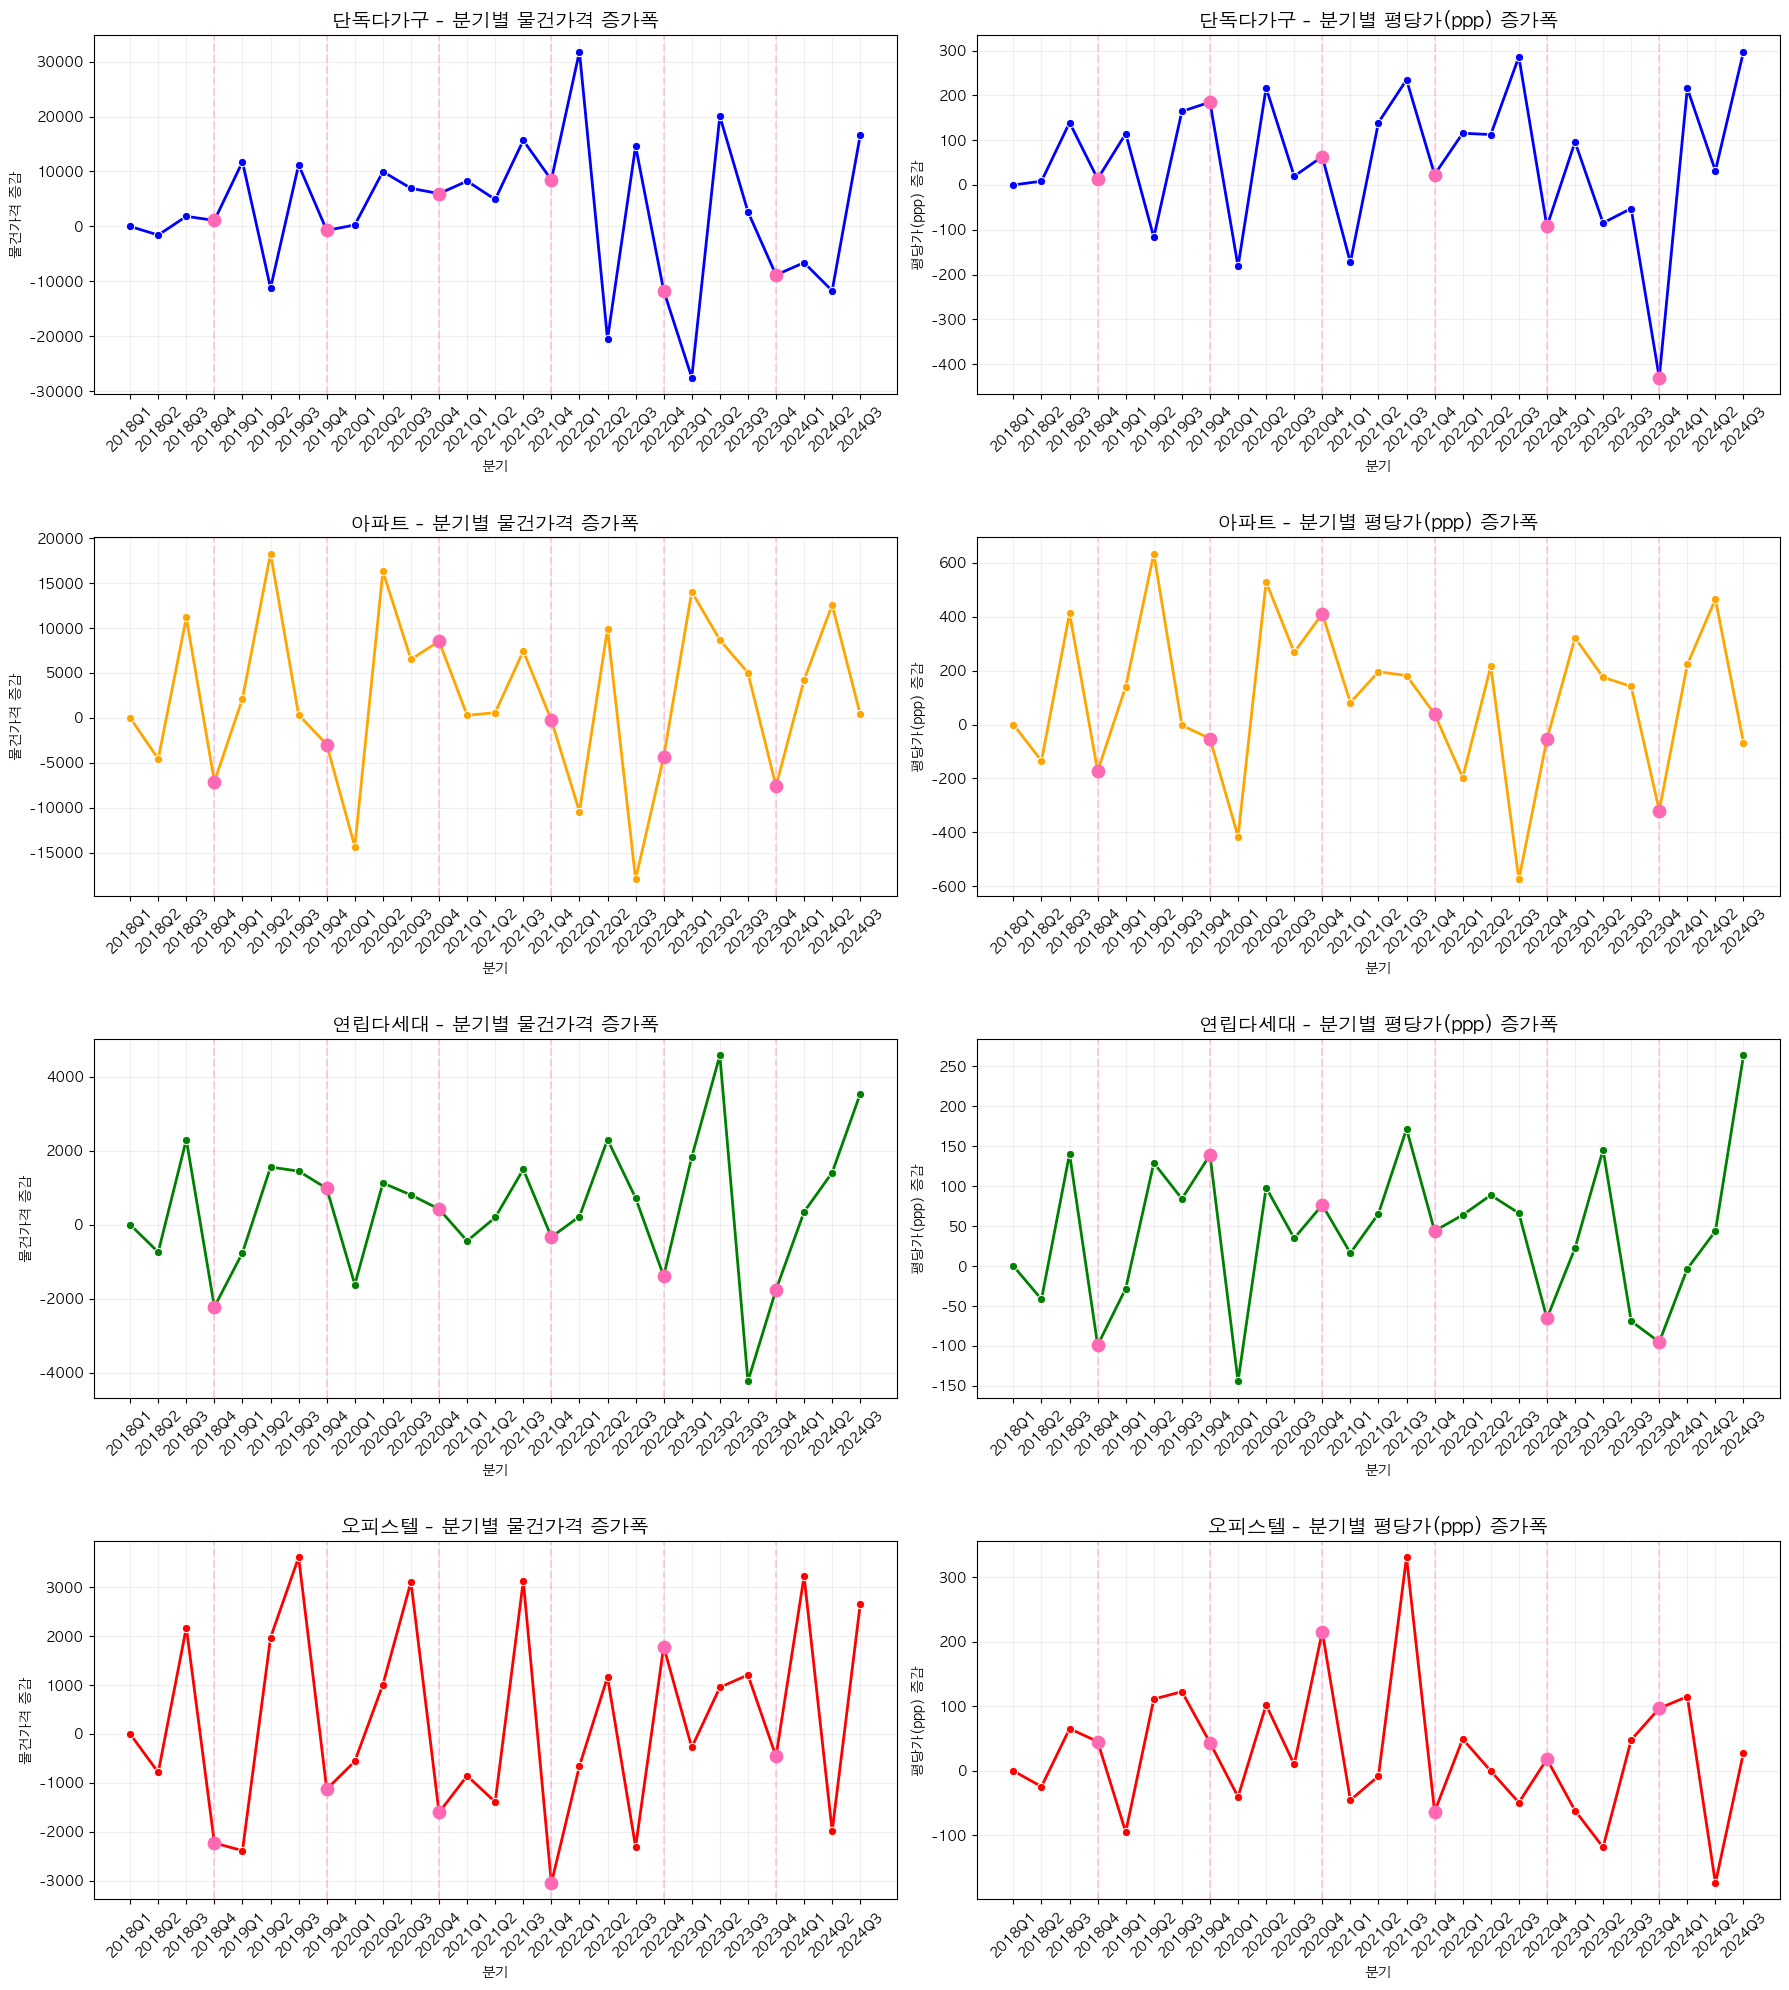

In [397]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 설정 및 데이터 리스트 준비
plt.rcParams['axes.unicode_minus'] = False 

# 각 행에 들어갈 데이터 (총액 데이터셋, 평당가 데이터셋)
rows_data = [
    (dan, dan2, '단독다가구'),
    (apt, apt2, '아파트'),
    (yeon, yeon2, '연립다세대'),
    (off, off2, '오피스텔')
]
colors = ['blue', 'orange', 'green', 'red']

# 2. 4행 2열 서브플롯 생성
fig, axes = plt.subplots(4, 2, figsize=(18, 20))

for i, (df_total, df_ppp, title) in enumerate(rows_data):
    # 각 행의 두 컬럼 데이터 지정
    sub_data = [(df_total, '물건가격'), (df_ppp, '평당가(ppp)')]
    
    for j, (df, y_label) in enumerate(sub_data):
        ax = axes[i, j]
        
        # 그래프 그리기
        sns.lineplot(data=df, x='bungi', y='diff', marker='o', 
                     linewidth=2, ax=ax, color=colors[i])
        
        # 4주기(연말) 강조 로직
        for idx, label in enumerate(df['bungi']):
            if label.endswith('Q4'):
                ax.axvline(x=idx, color='hotpink', linestyle='--', alpha=0.3)
                ax.scatter(idx, df['diff'].iloc[idx], color='hotpink', s=80, zorder=5)
        
        # 개별 그래프 설정
        ax.set_title(f"{title} - 분기별 {y_label} 증가폭", fontsize=14, fontweight='bold')
        ax.set_xlabel("분기")
        ax.set_ylabel(f"{y_label} 증감")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, axis='both', alpha=0.2)

# 전체 레이아웃 조정 및 간격 확보
plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # 행 간격 추가
plt.show()